<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/10_6_Exercise2_KMeans_Image_Compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 10.6 Exercise 2 — Image Compression with K-Means Clustering

**Task:** Using K-Means clustering, compress an image of size **396 x 396 x 3**.

## Dataset / Image

K-Means image compression (also called **color quantization**) works on any RGB image — the algorithm doesn't require a special labeled dataset, just pixel color values. This notebook uses the **`astronaut`** sample image bundled with the `scikit-image` library (a standard, freely-licensed image used throughout the scikit-image documentation and tutorials), resized to exactly **396 x 396 x 3** as requested in the exercise.

- **scikit-image sample images documentation:** https://scikit-image.org/docs/stable/api/skimage.data.html
- No external download is required — the image ships with the `scikit-image` package (`skimage.data.astronaut()`).

If you'd like to compress your **own** photo instead, simply replace the image-loading cell below with:
```python
from PIL import Image
img = np.array(Image.open('your_photo.jpg').resize((396, 396)))
```

**How K-Means compresses an image:** Each pixel is a point in 3D color space (R, G, B). K-Means clusters all pixels into `k` color groups and replaces every pixel with its cluster's centroid color. Instead of storing potentially millions of unique colors, the compressed image only needs `k` colors plus a per-pixel cluster label — this is the core idea behind color quantization / palette-based image compression (similar to how GIF images work).

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from skimage import data
from skimage.transform import resize
from PIL import Image

np.random.seed(42)
%matplotlib inline

## 2. Load and Resize the Image to 396 x 396 x 3

Original image shape: (512, 512, 3)
Resized image shape: (396, 396, 3), dtype: uint8


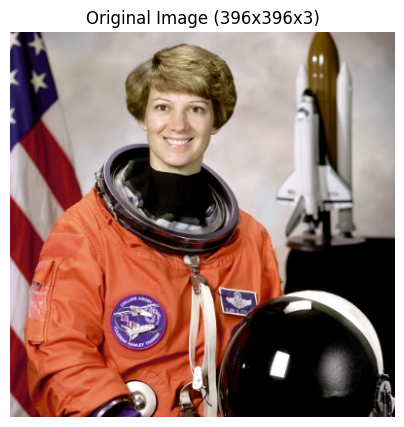

In [2]:
raw_img = data.astronaut()  # shape (512, 512, 3), dtype uint8
print(f"Original image shape: {raw_img.shape}")

# Resize to exactly 396 x 396 x 3 as requested in the exercise
img = resize(raw_img, (396, 396), anti_aliasing=True)
img = (img * 255).astype(np.uint8)  # resize() returns floats in [0,1]; convert back to uint8

print(f"Resized image shape: {img.shape}, dtype: {img.dtype}")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Original Image ({img.shape[0]}x{img.shape[1]}x{img.shape[2]})")
plt.axis('off')
plt.show()

## 3. Reshape the Image into a List of Pixels

K-Means expects a 2D array of samples (rows) x features (columns). Each pixel becomes one sample with 3 features (R, G, B).

In [3]:
h, w, c = img.shape
pixels = img.reshape(-1, 3).astype(np.float64)

print(f"Pixel array shape: {pixels.shape}  (i.e. {h*w} pixels, {c} color channels)")

unique_colors_original = len(np.unique(pixels.reshape(-1, 3), axis=0))
print(f"Number of unique colors in the original image: {unique_colors_original}")

Pixel array shape: (156816, 3)  (i.e. 156816 pixels, 3 color channels)
Number of unique colors in the original image: 74648


## 4. Apply K-Means Compression at Several Values of k

We'll compress the image down to just `k` colors, for a few different values of `k`, to see the quality/compression tradeoff.

In [4]:
def compress_image(pixels, img_shape, k, random_state=42):
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(pixels)
    centers = kmeans.cluster_centers_.astype(np.uint8)
    compressed_pixels = centers[labels]
    compressed_img = compressed_pixels.reshape(img_shape).astype(np.uint8)
    return compressed_img, kmeans

k_values = [2, 4, 8, 16, 32, 64]
compressed_images = {}

for k in k_values:
    compressed_img, kmeans_model = compress_image(pixels, img.shape, k)
    compressed_images[k] = compressed_img
    print(f"k={k:>3}: compressed using {k} colors")

k=  2: compressed using 2 colors
k=  4: compressed using 4 colors
k=  8: compressed using 8 colors
k= 16: compressed using 16 colors
k= 32: compressed using 32 colors
k= 64: compressed using 64 colors


## 5. Visualize Original vs. Compressed Images

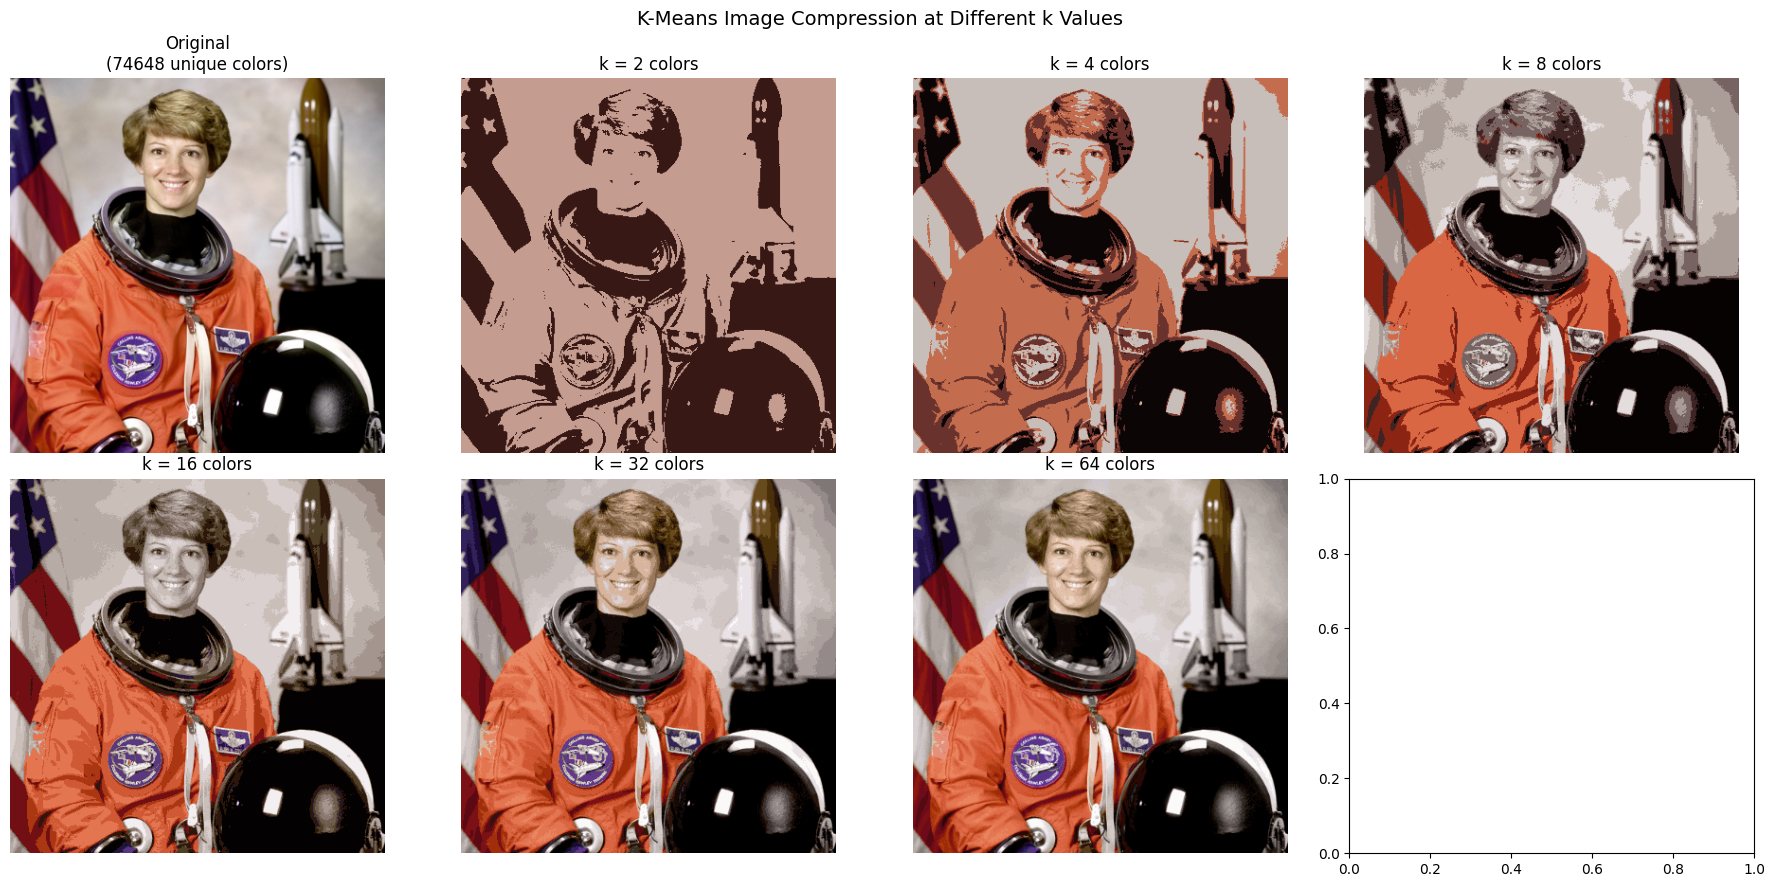

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(img)
axes[0, 0].set_title(f"Original\n({unique_colors_original} unique colors)")
axes[0, 0].axis('off')

flat_axes = axes.flatten()[1:]
for ax, k in zip(flat_axes, k_values):
    ax.imshow(compressed_images[k])
    ax.set_title(f"k = {k} colors")
    ax.axis('off')

plt.suptitle("K-Means Image Compression at Different k Values", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Quantify the Compression: Storage Size Comparison

An **uncompressed** image stores 3 bytes (R,G,B) per pixel. A **K-Means-compressed** image only needs to store:
- A small **color palette**: `k` colors x 3 bytes each
- A **label per pixel**: enough bits to represent `k` cluster indices (e.g., `ceil(log2(k))` bits per pixel instead of 24 bits)

In [6]:
import math

n_pixels = h * w
original_size_bytes = n_pixels * 3  # 3 bytes per pixel (R,G,B), 8 bits each

print(f"{'k':>5} | {'Palette (bytes)':>16} | {'Labels (bytes)':>16} | {'Total (bytes)':>14} | {'Compression Ratio':>18}")
print("-" * 80)
for k in k_values:
    palette_bytes = k * 3
    bits_per_label = math.ceil(math.log2(k))
    label_bytes = math.ceil(n_pixels * bits_per_label / 8)
    total_bytes = palette_bytes + label_bytes
    ratio = original_size_bytes / total_bytes
    print(f"{k:>5} | {palette_bytes:>16,} | {label_bytes:>16,} | {total_bytes:>14,} | {ratio:>17.1f}x")

print(f"\nOriginal uncompressed size: {original_size_bytes:,} bytes ({original_size_bytes/1024:.1f} KB)")

    k |  Palette (bytes) |   Labels (bytes) |  Total (bytes) |  Compression Ratio
--------------------------------------------------------------------------------
    2 |                6 |           19,602 |         19,608 |              24.0x
    4 |               12 |           39,204 |         39,216 |              12.0x
    8 |               24 |           58,806 |         58,830 |               8.0x
   16 |               48 |           78,408 |         78,456 |               6.0x
   32 |               96 |           98,010 |         98,106 |               4.8x
   64 |              192 |          117,612 |        117,804 |               4.0x

Original uncompressed size: 470,448 bytes (459.4 KB)


## 7. Measure Compression Quality (Mean Squared Error)

How much visual information is lost at each `k`? We measure the mean squared error (MSE) between the original and compressed pixel values.

k=  2: MSE = 1906.72
k=  4: MSE = 660.46
k=  8: MSE = 259.55
k= 16: MSE = 111.93
k= 32: MSE = 53.51
k= 64: MSE = 27.72


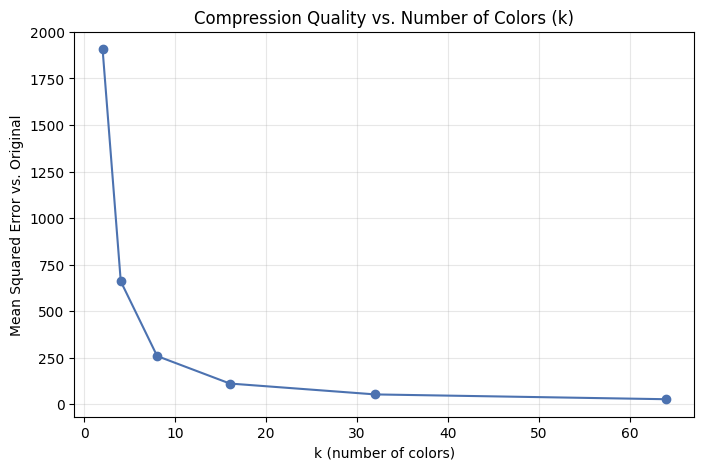

In [7]:
mse_values = []
for k in k_values:
    mse = np.mean((img.astype(np.float64) - compressed_images[k].astype(np.float64)) ** 2)
    mse_values.append(mse)
    print(f"k={k:>3}: MSE = {mse:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, mse_values, marker='o', color='#4C72B0')
plt.xlabel('k (number of colors)')
plt.ylabel('Mean Squared Error vs. Original')
plt.title('Compression Quality vs. Number of Colors (k)')
plt.grid(alpha=0.3)
plt.show()

As expected, **MSE decreases as `k` increases** — more colors means a closer approximation to the original image, at the cost of a larger palette (less compression).

## 8. Save the Compressed Image (Optional)

Let's save one compressed version (e.g., k=16) as an actual image file, to see the real-world compression benefit.

In [8]:
chosen_k = 16
output_img = Image.fromarray(compressed_images[chosen_k])
output_img.save('compressed_image_k16.png')

original_pil = Image.fromarray(img)
original_pil.save('original_image.png')

import os
original_file_size = os.path.getsize('original_image.png')
compressed_file_size = os.path.getsize('compressed_image_k16.png')

print(f"Original PNG file size:   {original_file_size:,} bytes ({original_file_size/1024:.1f} KB)")
print(f"Compressed (k=16) PNG file size: {compressed_file_size:,} bytes ({compressed_file_size/1024:.1f} KB)")
print(f"File size reduction: {(1 - compressed_file_size/original_file_size):.1%}")

Original PNG file size:   247,114 bytes (241.3 KB)
Compressed (k=16) PNG file size: 49,455 bytes (48.3 KB)
File size reduction: 80.0%


## Conclusion

- We compressed a **396x396x3** RGB image using **K-Means clustering** (color quantization): each pixel's (R,G,B) value was treated as a point in 3D color space, clustered into `k` groups, and replaced with its cluster centroid color.
- Reducing the color palette from potentially tens of thousands of unique colors down to just `k` colors (e.g., 16 or 32) achieves substantial compression while remaining visually close to the original.
- There's a clear **tradeoff between compression ratio and image quality (MSE)** — smaller `k` gives smaller file size but a more visibly "blocky"/posterized image, while larger `k` preserves more visual detail at the cost of a larger palette.
- This is the same principle used by real palette-based image formats like **GIF** and indexed-color PNGs.